# CNN_ACNE(SPOT)_CLASSIFICATION

In [6]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

In [7]:
import keras
from keras_preprocessing.image import ImageDataGenerator

from keras.callbacks import ModelCheckpoint

# for accuracy and Loss graph
import matplotlib.pyplot as plt

import tensorflow


In [8]:
train_data_path=r"C:\Users\vv\Downloads\New folder\ACNE_DETECTED\AcneDataset\train"
validation_data_path=r"C:\Users\vv\Downloads\New folder\ACNE_DETECTED\AcneDataset\valid"


In [9]:
# show augmented Images
def plotImages(images_arr):
    fig, axes=plt.subplots(1, 5, figsize=(20, 20))
    axes=axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)

    plt.tight_layout()
    plt.show()

# this is for augmentation configuration and we will use for traing
# It generates more images using below parameters

train_datagen = ImageDataGenerator(rescale=1./255, # to rescale the image in range of [0,1]
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2, # to randomly zoom the images
    shear_range=0.2, #to randomly shear the images
    horizontal_flip=True,
    fill_mode='nearest')

# this is a geenrator that will read found pictures
# at train_data_path and, indefinitely generate

training_data=train_datagen.flow_from_directory(train_data_path,target_size=(200,200),batch_size=128, class_mode='categorical')


    

Found 19038 images belonging to 2 classes.


In [10]:
training_data.class_indices

{'Acne': 0, 'Clear': 1}

In [11]:
# augmentation config for validation
# only rescaling

valid_datagen= ImageDataGenerator(rescale=1./255)


valid_data=valid_datagen.flow_from_directory(validation_data_path, target_size=(200,200), batch_size=128, class_mode='categorical')


Found 5727 images belonging to 2 classes.


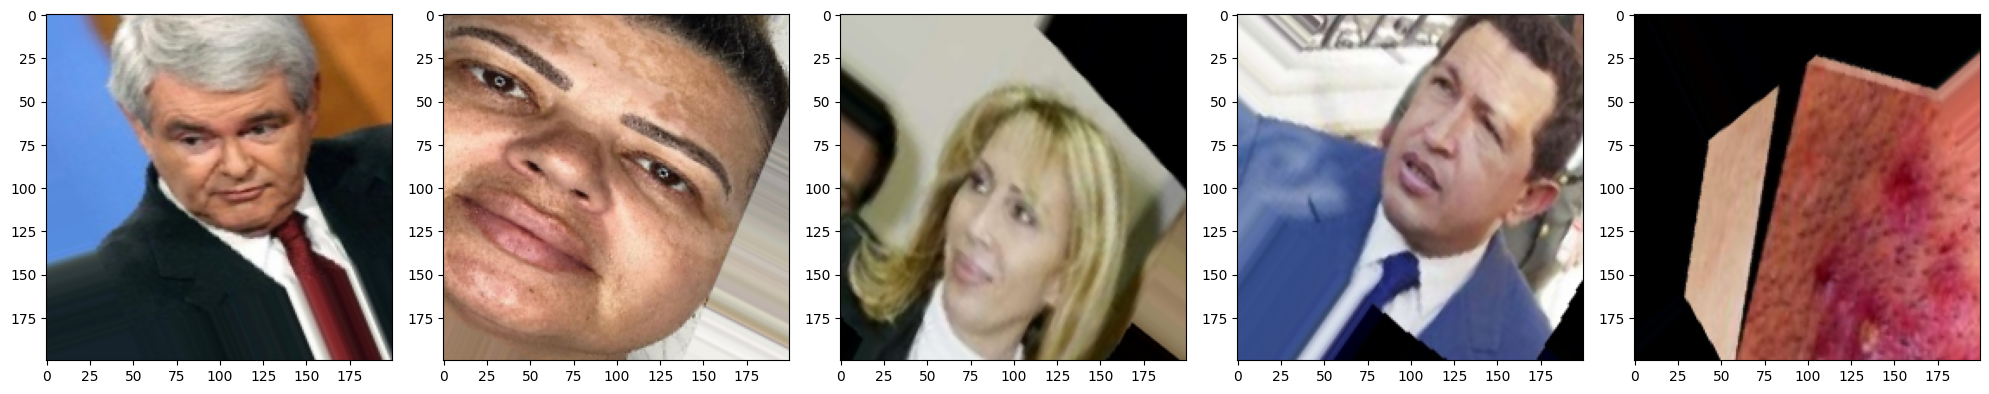

In [12]:
# showing augmented images
batch_images, batch_labels = training_data[0]

images = [batch_images[i] for i in range(5)]
plotImages(images)


# images=[training_data[0][0][0][0] for i in range(5)]
# plotImages(images)
# training_data[0]      # first batch
# [0]                   # images array
# [0]                   # first image
# [0]                   # first row of pixels

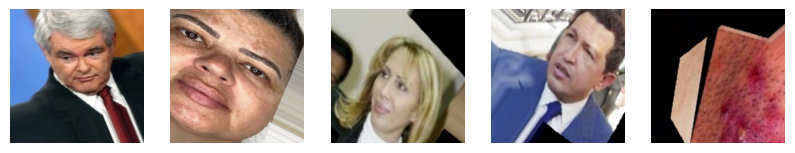

In [13]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(batch_images[i])
    plt.axis("off")

plt.show()

In [14]:
model_path='model/acne.h5'
checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list=[checkpoint]

In [20]:
from tensorflow import keras
from tensorflow.keras.optimizers import Adam

cnn_model = keras.models.Sequential([

    keras.layers.Conv2D(filters=32, kernel_size=5, activation='relu', input_shape=(200,200,3)),
    keras.layers.MaxPooling2D(pool_size=(4,4)),

    keras.layers.Conv2D(filters=64, kernel_size=4, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(3,3)),

    keras.layers.Conv2D(filters=128,kernel_size=3, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Conv2D(filters=256, kernel_size=2, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.25),
    
    keras.layers.Dense(units=2, activation='softmax')])


cnn_model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

# Batch Normalization is a technique that makes deep learning models train much faster and more reliably. 
# It acts like a stabilization layer that adjusts and standardizes the data flowing between the hidden layers of a neural network.

In [21]:
history=cnn_model.fit(training_data,epochs=5, verbose=1,  validation_data=valid_data, callbacks=callbacks_list)

Epoch 1/5
149/149 [==============================] - ETA: 0s - loss: 0.4208 - accuracy: 0.8048   
Epoch 1: val_accuracy improved from -inf to 0.92003, saving model to model\acne.h5
149/149 [==============================] - 940s 6s/step - loss: 0.4208 - accuracy: 0.8048 - val_loss: 0.2608 - val_accuracy: 0.9200
Epoch 2/5


C:\Users\vv\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


149/149 [==============================] - ETA: 0s - loss: 0.2538 - accuracy: 0.8964   
Epoch 2: val_accuracy improved from 0.92003 to 0.95041, saving model to model\acne.h5
149/149 [==============================] - 1236s 8s/step - loss: 0.2538 - accuracy: 0.8964 - val_loss: 0.1403 - val_accuracy: 0.9504
Epoch 3/5
149/149 [==============================] - ETA: 0s - loss: 0.1987 - accuracy: 0.9224   
Epoch 3: val_accuracy improved from 0.95041 to 0.97957, saving model to model\acne.h5
149/149 [==============================] - 606s 4s/step - loss: 0.1987 - accuracy: 0.9224 - val_loss: 0.0790 - val_accuracy: 0.9796
Epoch 4/5
149/149 [==============================] - ETA: 0s - loss: 0.1788 - accuracy: 0.9280   
Epoch 4: val_accuracy did not improve from 0.97957
149/149 [==============================] - 514s 3s/step - loss: 0.1788 - accuracy: 0.9280 - val_loss: 0.0626 - val_accuracy: 0.9794
Epoch 5/5
149/149 [==============================] - ETA: 0s - loss: 0.1336 - accuracy: 0.9499  

In [24]:
cnn_model.save('model/acne_clear.h5')
print("Model Saved")

Model Saved


In [29]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array

# =====================================
# LOAD MODEL
# =====================================

model = load_model("model/acne_clear.h5")

IMG_SIZE = 200

# =====================================
# FACE DETECTOR
# =====================================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

# =====================================
# START CAMERA
# =====================================

cap = cv2.VideoCapture(0)

font = cv2.FONT_HERSHEY_SIMPLEX

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=6
    )

    for (x, y, w, h) in faces:

        # Crop Face
        face = frame[y:y+h, x:x+w]

        # Resize
        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))

        # Normalize
        face = img_to_array(face)
        face = face.astype("float32") / 255.0
        face = np.expand_dims(face, axis=0)

        # Prediction
        prediction = model.predict(face, verbose=0)[0][0]

        # =====================================
        # CLASSIFICATION
        # =====================================

        if prediction >= 0.5:

            label = "Acne"

            confidence = prediction * 100

            color = (0, 0, 255)  # Red

        else:

            label = "Clear Face"

            confidence = (1 - prediction) * 100

            color = (0, 255, 0)  # Green

        # Draw Rectangle
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            color,
            3
        )

        # Display Label
        text = f"{label}: {confidence:.1f}%"

        cv2.putText(
            frame,
            text,
            (x, y-10),
            font,
            0.8,
            color,
            2,
            cv2.LINE_AA
        )

        print(text)

    cv2.imshow("Acne vs Clear Detection", frame)

    # ESC key to quit
    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

Clear Face: 73.1%
Clear Face: 77.4%
Clear Face: 68.8%
Clear Face: 71.6%
Clear Face: 64.3%
Clear Face: 65.9%
Clear Face: 54.8%
Clear Face: 55.1%
Clear Face: 58.6%
Clear Face: 55.9%
Clear Face: 53.7%
Clear Face: 54.0%
Clear Face: 52.4%
Clear Face: 53.6%
Clear Face: 54.8%
Clear Face: 50.4%
Clear Face: 52.8%
Clear Face: 54.5%
Clear Face: 51.2%
Clear Face: 53.7%
Clear Face: 52.6%
Clear Face: 52.5%
Clear Face: 50.1%
Clear Face: 53.0%
Clear Face: 57.5%
Clear Face: 51.0%
Clear Face: 53.0%
Clear Face: 53.1%
Clear Face: 59.4%
Clear Face: 52.5%
